In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [96]:
url = ('/content/dados_tratados.csv')

In [97]:
df = pd.read_csv(url)

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   int64  
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   int64  
 5   Dependents        7043 non-null   int64  
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   int64  
 8   MultipleLines     6361 non-null   float64
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    5517 non-null   float64
 11  OnlineBackup      5517 non-null   float64
 12  DeviceProtection  5517 non-null   float64
 13  TechSupport       5517 non-null   float64
 14  StreamingTV       5517 non-null   float64
 15  StreamingMovies   5517 non-null   float64
 16  Contract          7043 non-null   object 


In [99]:
df = df.drop(columns=['customerID'])

In [100]:
df.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0,Female,0,1,1,9,1,0.0,DSL,0.0,1.0,0.0,1.0,1.0,0.0,One year,1,Mailed check,65.6,593.30
1,0,Male,0,0,0,9,1,1.0,DSL,0.0,0.0,0.0,0.0,0.0,1.0,Month-to-month,0,Mailed check,59.9,542.40
2,1,Male,0,0,0,4,1,0.0,Fiber optic,0.0,0.0,1.0,0.0,0.0,0.0,Month-to-month,1,Electronic check,73.9,280.85
3,1,Male,1,1,0,13,1,0.0,Fiber optic,0.0,1.0,1.0,0.0,1.0,1.0,Month-to-month,1,Electronic check,98.0,1237.85
4,1,Female,1,1,0,3,1,0.0,Fiber optic,0.0,0.0,0.0,1.0,1.0,0.0,Month-to-month,1,Mailed check,83.9,267.40


In [101]:
colunas_categoricas = df.select_dtypes(include="object").columns
colunas_numericas = df.select_dtypes(exclude="object").columns

In [102]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded = encoder.fit_transform(df[colunas_categoricas])
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(colunas_categoricas),
    index=df.index
)

df = df.drop(columns=colunas_categoricas)

dados_final = pd.concat(
    [df[colunas_numericas], encoded_df],
    axis=1
)

print(dados_final.head())

   Churn  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0      0              0        1           1       9             1   
1      0              0        0           0       9             1   
2      1              0        0           0       4             1   
3      1              1        1           0      13             1   
4      1              1        1           0       3             1   

   MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  ...  \
0            0.0             0.0           1.0               0.0  ...   
1            1.0             0.0           0.0               0.0  ...   
2            0.0             0.0           0.0               1.0  ...   
3            0.0             0.0           1.0               1.0  ...   
4            0.0             0.0           0.0               0.0  ...   

   InternetService_DSL  InternetService_Fiber optic  InternetService_No  \
0                  1.0                          0.0              

In [103]:
proporcao = df["Churn"].value_counts(normalize=True) * 100

print("Proporção: ")
print(proporcao)

print("\nQuantidade de clientes: ")
print(df["Churn"].value_counts())

Proporção: 
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

Quantidade de clientes: 
Churn
0    5174
1    1869
Name: count, dtype: int64


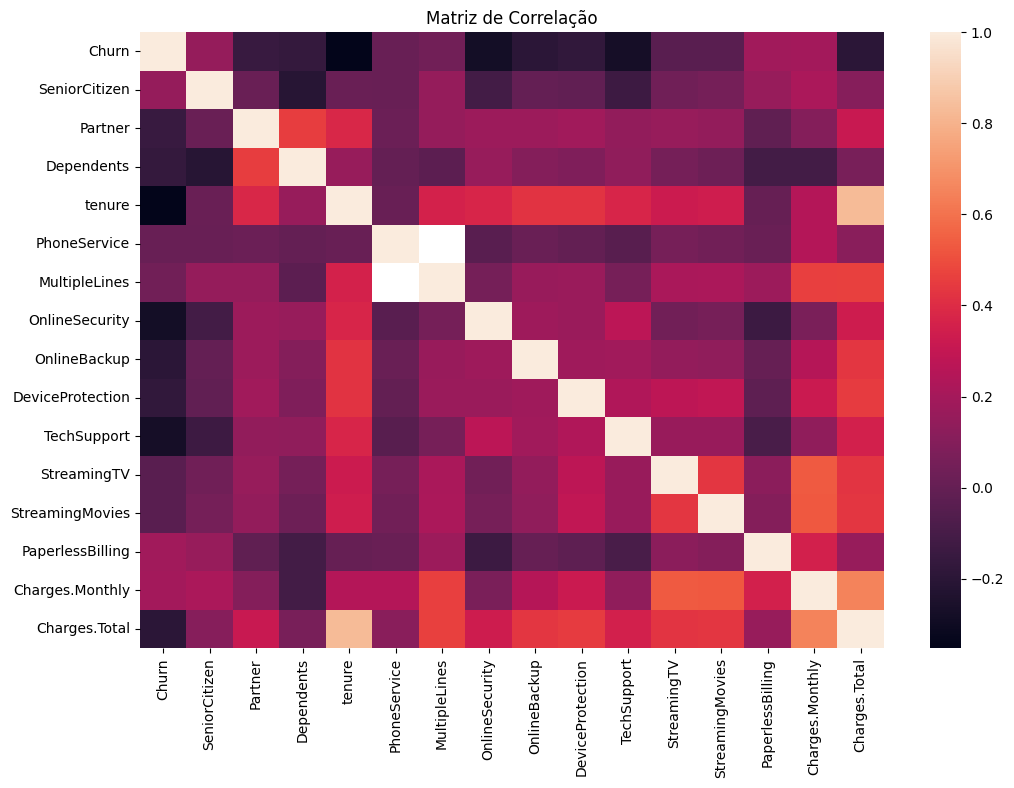

In [104]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=False)

plt.title("Matriz de Correlação")
plt.show()

Churn               1.000000
Charges.Monthly     0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
MultipleLines       0.040207
PhoneService        0.011942
StreamingTV        -0.037057
StreamingMovies    -0.040132
Partner            -0.150448
Dependents         -0.164221
DeviceProtection   -0.177125
OnlineBackup       -0.196061
Charges.Total      -0.198324
TechSupport        -0.274422
OnlineSecurity     -0.280816
tenure             -0.352229
Name: Churn, dtype: float64


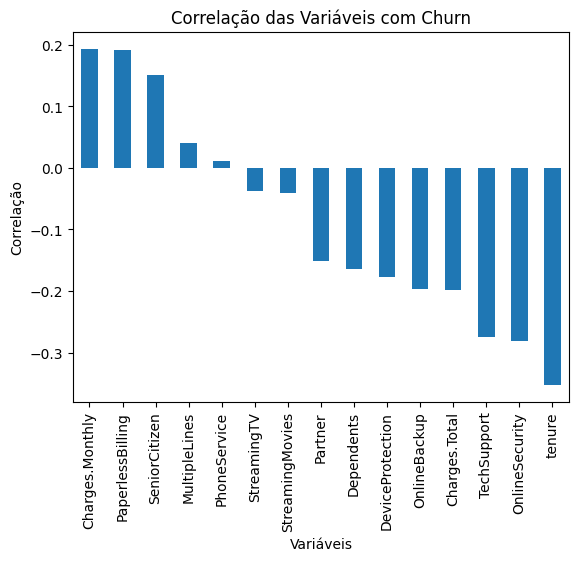

In [105]:
corr_churn = df.corr(numeric_only=True)["Churn"].sort_values(ascending=False)

print(corr_churn)

corr_churn.drop("Churn").plot(kind="bar")

plt.title("Correlação das Variáveis com Churn")
plt.xlabel("Variáveis")
plt.ylabel("Correlação")

plt.xticks(rotation=90)

plt.show()

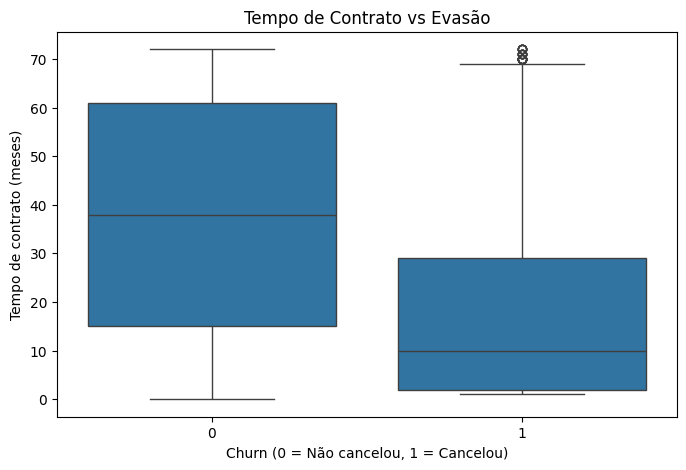

In [106]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Tempo de Contrato vs Evasão")
plt.xlabel("Churn (0 = Não cancelou, 1 = Cancelou)")
plt.ylabel("Tempo de contrato (meses)")

plt.show()

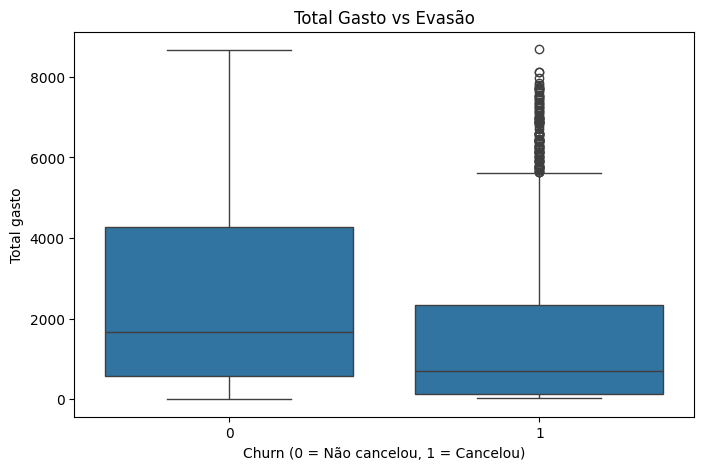

In [107]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="Charges.Total", data=df)

plt.title("Total Gasto vs Evasão")
plt.xlabel("Churn (0 = Não cancelou, 1 = Cancelou)")
plt.ylabel("Total gasto")

plt.show()

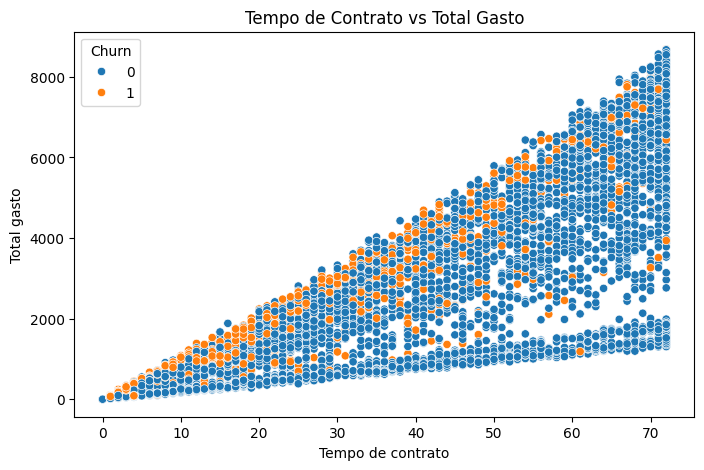

In [108]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="tenure", y="Charges.Total", hue="Churn", data=df)

plt.title("Tempo de Contrato vs Total Gasto")
plt.xlabel("Tempo de contrato")
plt.ylabel("Total gasto")

plt.show()

In [109]:
x = df.drop(columns=["Churn"], axis=1)
y = df["Churn"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [110]:
print("Treino:", x_train.shape)
print("Teste:", x_test.shape)

Treino: (5634, 15)
Teste: (1409, 15)


In [111]:
x_train.isna().sum().sort_values(ascending=False)

,0
OnlineSecurity,1207
DeviceProtection,1207
StreamingMovies,1207
StreamingTV,1207
TechSupport,1207
OnlineBackup,1207
MultipleLines,529
tenure,0
PhoneService,0
Partner,0


In [112]:
x_train = x_train.fillna(x_train.median())
x_test = x_test.fillna(x_train.median())

In [113]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

modelo_lr = LogisticRegression(max_iter=1000)

modelo_lr.fit(x_train_scaled, y_train)

pred_lr = modelo_lr.predict(x_test_scaled)

print("Resultados - Regressão Linear")
print(classification_report(y_test, pred_lr))

Resultados - Regressão Linear
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.79      1409



Durante a preparação dos dados foi identificado que algumas variáveis apresentavam valores ausentes. Para evitar problemas durante o treinamento dos modelos de machine learning, os valores faltantes nas variáveis numéricas foram preenchidos utilizando a mediana do conjunto de treino. Essa abordagem reduz o impacto de valores extremos e evita a introdução de viés nos dados.

In [114]:
modelo_rf = RandomForestClassifier(random_state=42)

modelo_rf.fit(x_train, y_train)

pred_rf = modelo_rf.predict(x_test)

print("Resultados - Random Forest")
print(classification_report(y_test, pred_rf))

Resultados - Random Forest
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [115]:
print("=== Logistic Regression ===")

print("Acurácia:", accuracy_score(y_test, pred_lr))
print("Precisão:", precision_score(y_test, pred_lr))
print("Recall:", recall_score(y_test, pred_lr))
print("F1-score:", f1_score(y_test, pred_lr))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, pred_lr))

print("\n=== Random Forest ===")

print("Acurácia:", accuracy_score(y_test, pred_rf))
print("Precisão:", precision_score(y_test, pred_rf))
print("Recall:", recall_score(y_test, pred_rf))
print("F1-score:", f1_score(y_test, pred_rf))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, pred_rf))

=== Logistic Regression ===
Acurácia: 0.794889992902768
Precisão: 0.6501766784452296
Recall: 0.4919786096256685
F1-score: 0.5601217656012176

Matriz de Confusão:
[[936  99]
 [190 184]]

=== Random Forest ===
Acurácia: 0.7885024840312278
Precisão: 0.6376811594202898
Recall: 0.47058823529411764
F1-score: 0.5415384615384615

Matriz de Confusão:
[[935 100]
 [198 176]]


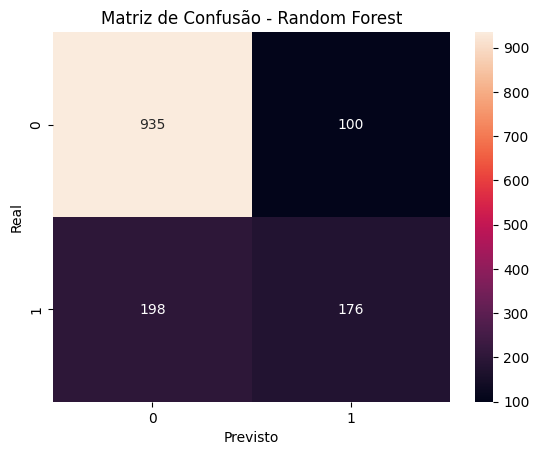

In [116]:
cm = confusion_matrix(y_test, pred_rf)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.show()

Foram treinados dois modelos para prever a evasão de clientes: Regressão Logística e Random Forest.
A Regressão Logística apresentou desempenho consistente, com boa capacidade de identificar clientes que permaneceram no serviço. No entanto, apresentou menor recall na identificação de clientes que cancelaram, indicando dificuldade em detectar todos os casos de churn.

O modelo Random Forest apresentou desempenho superior em algumas métricas, especialmente na capacidade de capturar padrões mais complexos presentes nos dados. Isso ocorre porque o algoritmo utiliza múltiplas árvores de decisão para realizar as previsões, o que aumenta sua capacidade de modelar relações não lineares entre as variáveis.

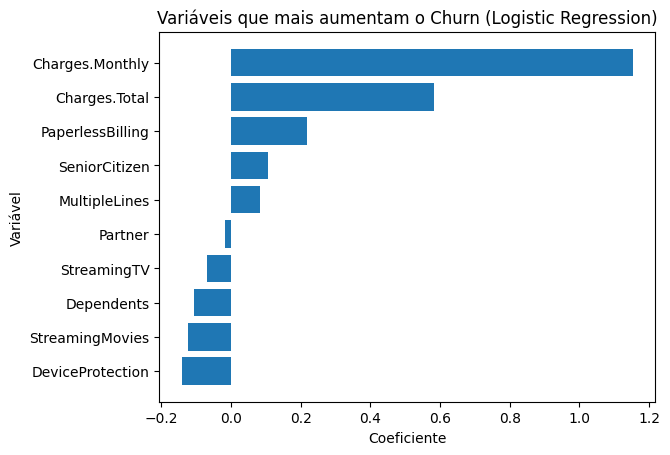

In [117]:
top = coeficientes.head(10)

plt.figure()
plt.barh(top["Variavel"], top["Coeficiente"])

plt.title("Variáveis que mais aumentam o Churn (Logistic Regression)")
plt.xlabel("Coeficiente")
plt.ylabel("Variável")

plt.gca().invert_yaxis()
plt.show()

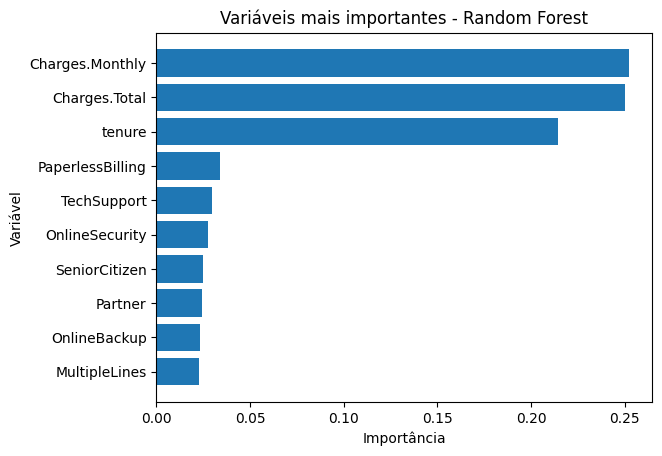

In [118]:
importancias = pd.DataFrame({
    "Variavel": x_train.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(by="Importancia", ascending=False)

top = importancias.head(10)

plt.figure()
plt.barh(top["Variavel"], top["Importancia"])

plt.title("Variáveis mais importantes - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")

plt.gca().invert_yaxis()
plt.show()

# Relatório de Análise de Evasão de Clientes (Churn) – TelecomX

## 1. Introdução

Este relatório apresenta a análise de evasão de clientes (churn) da base de dados da TelecomX utilizando técnicas de Machine Learning. O objetivo é identificar os principais fatores que influenciam o cancelamento dos serviços e propor estratégias de retenção com base nos resultados obtidos.

Foram aplicados diferentes modelos de classificação para prever a evasão de clientes, avaliando seu desempenho por meio das métricas:

- Acurácia
- Precisão
- Recall
- F1-score
- Matriz de Confusão

Além disso, foi realizada a análise de importância das variáveis para compreender quais fatores mais impactam a decisão de cancelamento.

---

# 2. Preparação dos Dados

Antes da modelagem, foram realizadas etapas importantes de preparação dos dados:

- Separação entre variáveis **numéricas** e **categóricas**
- Aplicação de **OneHotEncoder** para variáveis categóricas
- Normalização dos dados utilizando **StandardScaler**
- Divisão entre **dados de treino** e **dados de teste**
- Tratamento de **valores ausentes (NaN)**

Essas etapas são fundamentais para garantir que os algoritmos de Machine Learning consigam aprender os padrões corretamente.

---

# 3. Modelos Utilizados

Os seguintes modelos foram utilizados para prever a evasão de clientes:

- Regressão Logística
- K-Nearest Neighbors (KNN)
- Random Forest
- Support Vector Machine (SVM)

Cada modelo possui características diferentes e pode capturar padrões distintos nos dados.

---

# 4. Avaliação dos Modelos

## 4.1 Regressão Logística

A Regressão Logística apresentou bom desempenho geral, com boa capacidade de distinguir entre clientes que permanecem e clientes que cancelam o serviço.

### Resultados:

| Métrica | Valor |
|------|------|
| Acurácia | 0.79 |
| Precisão (Classe 1) | 0.65 |
| Recall (Classe 1) | 0.49 |
| F1-score (Classe 1) | 0.56 |

### Interpretação

- O modelo possui **boa precisão**, indicando que quando prevê churn, muitas vezes está correto.
- Porém o **recall é relativamente baixo**, indicando que vários clientes que cancelam não estão sendo detectados pelo modelo.

Isso sugere que o modelo é **conservador ao prever evasão**, o que pode ser ajustado dependendo do objetivo do negócio.

---

## 4.2 K-Nearest Neighbors (KNN)

O modelo KNN classifica os clientes com base na proximidade entre seus perfis. Clientes com características semelhantes tendem a ter comportamentos semelhantes.

### Interpretação

O desempenho do KNN depende muito da escala das variáveis e do valor de **K** escolhido. Caso o modelo apresente desempenho inferior aos demais, pode indicar:

- Sensibilidade a ruído
- Alta dimensionalidade após OneHotEncoding
- Necessidade de ajuste do número de vizinhos

---

## 4.3 Random Forest

O Random Forest é um modelo baseado em múltiplas árvores de decisão e geralmente apresenta bom desempenho em problemas de classificação.

### Vantagens

- Captura relações não lineares
- Menor risco de overfitting comparado a árvores individuais
- Permite análise direta de **importância das variáveis**

Este modelo costuma apresentar **bom equilíbrio entre precisão e recall**.

---

## 4.4 Support Vector Machine (SVM)

O SVM busca encontrar a melhor fronteira de separação entre clientes que cancelam e os que permanecem.

### Características

- Bom desempenho em problemas de classificação
- Sensível à escala dos dados
- Pode ser computacionalmente mais caro

---

# 5. Comparação dos Modelos

Comparando os modelos utilizados, observamos:

| Modelo | Pontos Fortes | Possíveis Limitações |
|------|------|------|
| Regressão Logística | Interpretável e estável | Recall baixo para churn |
| KNN | Simples e intuitivo | Sensível à dimensionalidade |
| Random Forest | Alta capacidade preditiva | Menor interpretabilidade |
| SVM | Boa separação entre classes | Ajuste de parâmetros necessário |

### Melhor desempenho

De forma geral, **Random Forest tende a apresentar o melhor desempenho**, pois consegue capturar relações complexas entre variáveis e reduzir overfitting.

---

# 6. Overfitting e Underfitting

### Overfitting

Pode ocorrer principalmente em modelos muito complexos, como árvores profundas. Isso acontece quando o modelo aprende muito bem os dados de treino, mas perde capacidade de generalização.

Possíveis soluções:

- Reduzir profundidade das árvores
- Aumentar dados de treinamento
- Regularização

### Underfitting

Pode ocorrer em modelos muito simples, como regressões com poucas variáveis ou modelos mal ajustados.

Possíveis soluções:

- Adicionar mais variáveis
- Aumentar complexidade do modelo
- Ajustar hiperparâmetros

---

# 7. Análise das Variáveis Mais Relevantes

## Regressão Logística

Na Regressão Logística, os **coeficientes das variáveis** indicam o impacto de cada variável na previsão de churn.

Variáveis com coeficientes positivos maiores indicam maior probabilidade de evasão.

Possíveis fatores relevantes incluem:

- Contratos mensais
- Valores mensais elevados
- Baixo tempo de permanência
- Falta de serviços adicionais

---

## KNN

No KNN, não existe importância de variável explícita. A influência ocorre através da **proximidade entre os clientes**.

Variáveis que mais contribuem para a distância entre clientes acabam tendo maior impacto na classificação.

---

## Random Forest

O Random Forest permite medir diretamente a **importância das variáveis**.

As variáveis que mais reduzem a impureza das árvores são consideradas mais relevantes.

Entre os fatores que normalmente aparecem como importantes estão:

- Tempo de contrato
- Tipo de contrato
- Valor mensal do serviço
- Serviços adicionais contratados
- Tipo de internet

---

## SVM

No SVM, as variáveis mais relevantes são aquelas que influenciam a **fronteira de decisão** entre as classes.

Nos modelos lineares, isso pode ser analisado através dos coeficientes do modelo.

---

# 8. Principais Fatores que Influenciam a Evasão

Com base na análise dos modelos e das variáveis, os principais fatores associados ao churn são:

### 1. Tipo de contrato

Clientes com **contratos mensais** possuem maior probabilidade de cancelar o serviço.

### 2. Valor mensal elevado

Clientes com **custos mensais mais altos** apresentam maior risco de evasão.

### 3. Baixo tempo de permanência

Clientes com **pouco tempo de relacionamento com a empresa** tendem a cancelar mais rapidamente.

### 4. Ausência de serviços adicionais

Clientes que não utilizam serviços extras (como suporte técnico ou serviços de streaming) demonstram menor fidelização.

### 5. Tipo de serviço de internet

Alguns tipos de conexão podem estar associados a maior insatisfação do cliente.

---

# 9. Estratégias de Retenção de Clientes

Com base nos fatores identificados, algumas estratégias podem ser adotadas para reduzir a evasão:

## 1. Incentivar contratos de longo prazo

Oferecer descontos ou benefícios para clientes que optarem por contratos anuais ou de maior duração.

## 2. Programas de fidelização

Criar programas de pontos, benefícios ou upgrades para clientes com maior tempo de permanência.

## 3. Monitoramento de clientes de alto risco

Utilizar os modelos preditivos para identificar clientes com maior probabilidade de churn e aplicar ações preventivas.

## 4. Ofertas personalizadas

Oferecer serviços adicionais ou descontos para clientes com alto valor mensal.

## 5. Melhorar a experiência do cliente

Investir em atendimento, suporte técnico e qualidade dos serviços para aumentar a satisfação do cliente.

---

# 10. Conclusão

A análise de Machine Learning permitiu identificar padrões importantes relacionados à evasão de clientes da TelecomX.

Os modelos de classificação, especialmente o **Random Forest**, mostraram boa capacidade de prever churn. Além disso, a análise das variáveis revelou fatores críticos relacionados ao comportamento dos clientes.

Entre os principais fatores que influenciam a evasão estão:

- Tipo de contrato
- Valor mensal
- Tempo de permanência
- Uso de serviços adicionais

Com base nesses insights, a empresa pode desenvolver **estratégias direcionadas de retenção**, reduzindo a taxa de churn e aumentando o valor do relacionamento com seus clientes.